# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año?  
> ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

## 1. Import y carga

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# sns.set_theme(style='whitegrid')
# plt.rcParams['figure.figsize'] = (10, 5)
# plt.rcParams['axes.titlesize'] = 13
# plt.rcParams['axes.labelsize'] = 11

In [95]:
CSV_PATH = r'..\Data\DatasetClean_2026-06-29.csv'

df = pd.read_csv(CSV_PATH)
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

Filas: 702 | Columnas: 26


In [96]:
# Diccionario meses
MESOS = {
    0: 'Sin mes', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
df['Month_Absence_Desc'] = df['Month_Absence'].map(MESOS)

# Clasificación de motivos: médico ICD (1-21) vs no médico (22-28) vs sin código (0)
def tipus_motiu(codi):
    if codi == 0: return 'Sin código'
    if codi <= 21: return 'Médico ICD (1-21)'
    return 'No médico (22-28)'

df['Tipus_Motiu'] = df['Reason_Absence'].apply(tipus_motiu)

## 2. Magnitud del absentismo

In [115]:
col = 'Absenteeism_Hours'

print(' Estadística descriptiva — Absenteeism_Hours ')
print(df[col].describe().round(2))
print(f'\nAsimetría (skewness): {df[col].skew():.2f}')
print(f'\nHoras totales de absentismo:   {df[col].sum():,.0f} h')
print(f'Media por episodio:            {df[col].mean():.1f} h')
print(f'Mediana por episodio:          {df[col].median():.1f} h')
print(f'\nDiferencia media-mediana: {df[col].mean() - df[col].median():.1f} h')

 Estadística descriptiva — Absenteeism_Hours 
count    702.00
mean       7.18
std       13.64
min        0.00
25%        2.00
50%        3.00
75%        8.00
max      120.00
Name: Absenteeism_Hours, dtype: float64

Asimetría (skewness): 5.58

Horas totales de absentismo:   5,043 h
Media por episodio:            7.2 h
Mediana por episodio:          3.0 h

Diferencia media-mediana: 4.2 h


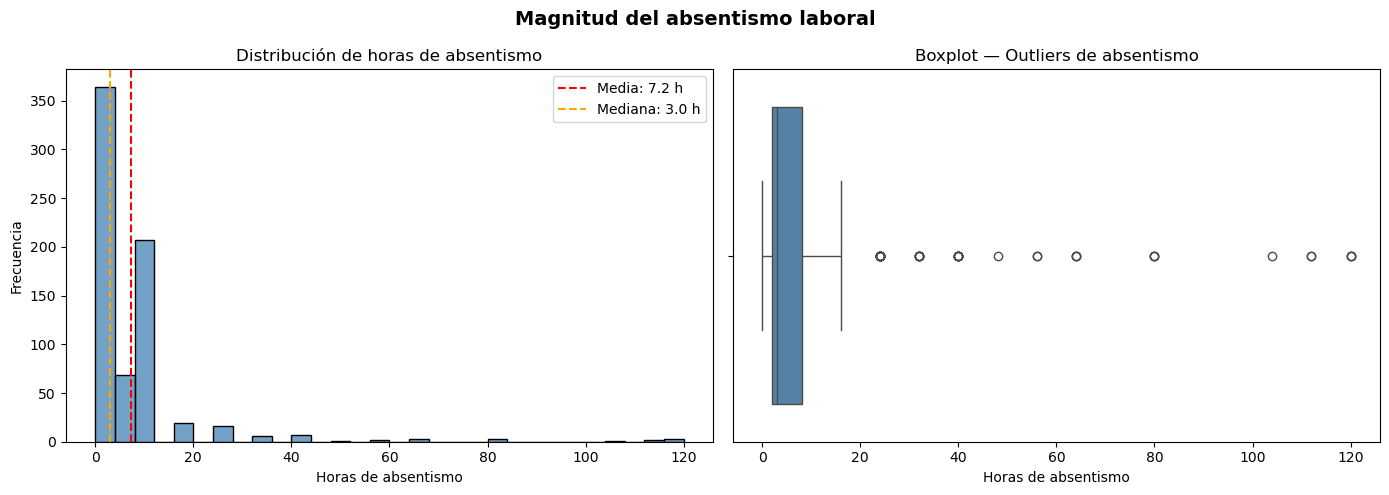

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[col], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Media: {df[col].mean():.1f} h')
axes[0].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana: {df[col].median():.1f} h')
axes[0].set_title('Distribución de horas de absentismo')
axes[0].set_xlabel('Horas de absentismo')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

sns.boxplot(x=df[col], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot — Outliers de absentismo')
axes[1].set_xlabel('Horas de absentismo')

plt.suptitle('Magnitud del absentismo laboral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## JUSTIFICACIÓN TÉCNICA -veronica

Distribución muy sesgada a la derecha (muchas absencias cortas y unas pocas muy largas)  
Se usará Spearman para las correlaciones (más robusto pq trabaja con rango en vez de valores absolutos)  
Se usará la mediana como medida central.


In [100]:
# Horas totales por empleado
abs_per_empleat = df.groupby('ID_Employee')[col].agg(
    total_horas='sum',
    num_episodios='count',
    mediana_horas='median'
).round(1).sort_values('total_horas', ascending=False)


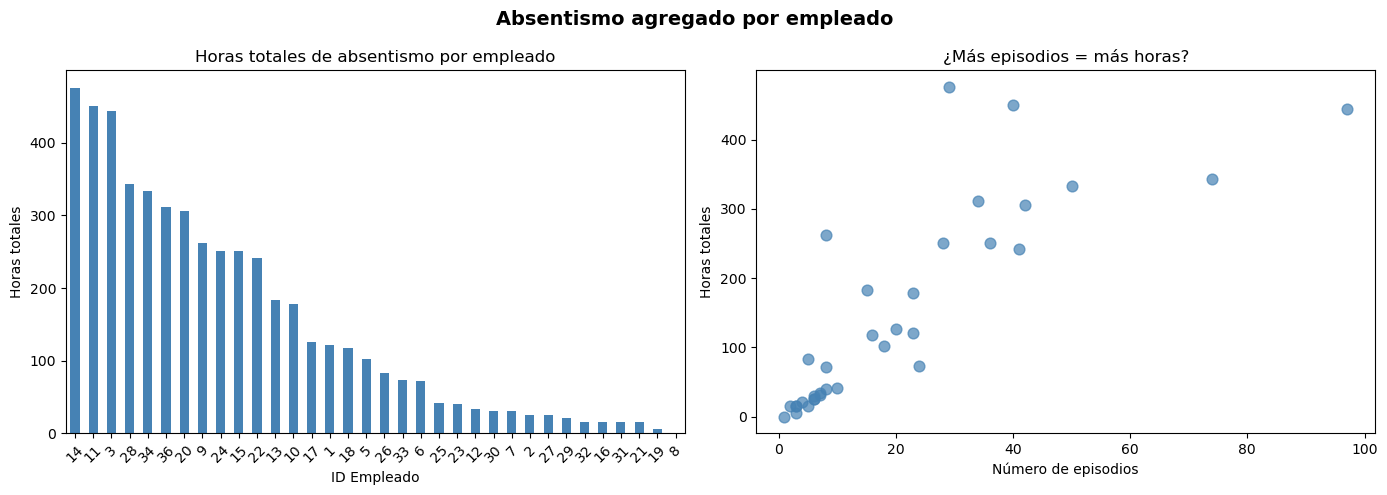

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abs_per_empleat['total_horas'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Horas totales de absentismo por empleado')
axes[0].set_xlabel('ID Empleado')
axes[0].set_ylabel('Horas totales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(abs_per_empleat['num_episodios'], abs_per_empleat['total_horas'],
                alpha=0.7, color='steelblue', s=60)
axes[1].set_title('¿Más episodios = más horas?')
axes[1].set_xlabel('Número de episodios')
axes[1].set_ylabel('Horas totales')

plt.suptitle('Absentismo agregado por empleado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Variación temporal

**suma** de horas para ver el impacto total en la empresa, **mediana** para ver la intensidad de cada episodio.

**Nota** excluímos registros con `Month_Absence = 0`.

In [102]:
df_mesos = df[df['Month_Absence'] != 0].copy()
print(f'Registros con mes válido: {len(df_mesos)} (eliminados {len(df) - len(df_mesos)} con Month=0)')

Registros con mes válido: 702 (eliminados 0 con Month=0)


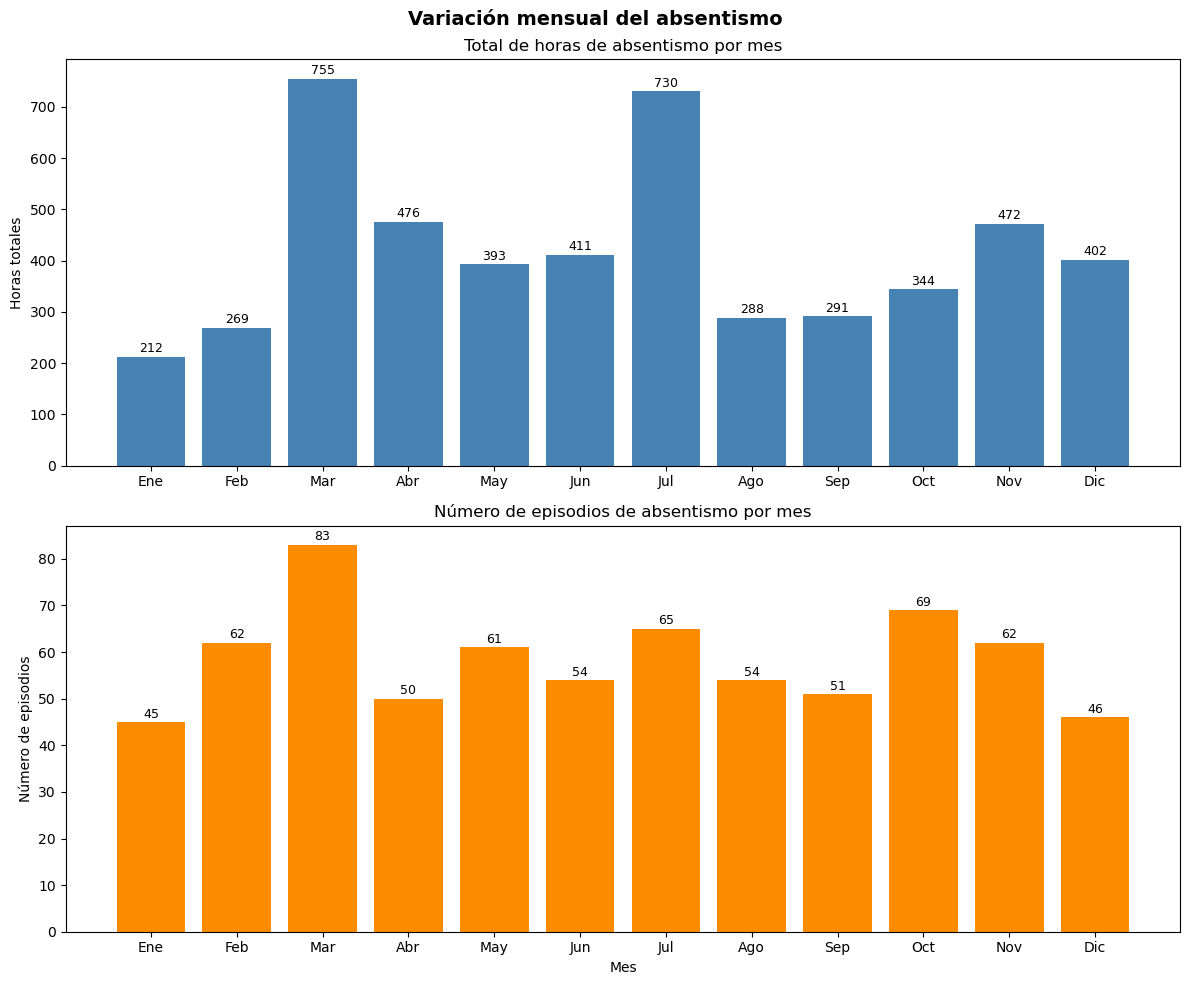

Mes con más horas totales:  Mar
Mes con menos horas totales: Ene


In [103]:
# Absentismo por mes
ordre_mesos = [MESOS[m] for m in range(1, 13)]

abs_mes = df_mesos.groupby('Month_Absence_Desc')[col].agg(
    total_horas='sum',
    num_episodios='count',
    mediana_horas='median'
).reindex(ordre_mesos).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

bars = axes[0].bar(abs_mes['Month_Absence_Desc'], abs_mes['total_horas'], color='steelblue')
for bar, val in zip(bars, abs_mes['total_horas']):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     str(int(val)), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Total de horas de absentismo por mes')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_mes['Month_Absence_Desc'], abs_mes['num_episodios'], color='darkorange')
for bar, val in zip(bars2, abs_mes['num_episodios']):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(int(val)), ha='center', va='bottom', fontsize=9)
axes[1].set_title('Número de episodios de absentismo por mes')
axes[1].set_ylabel('Número de episodios')
axes[1].set_xlabel('Mes')

plt.suptitle('Variación mensual del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mes_max = abs_mes.loc[abs_mes['total_horas'].idxmax(), 'Month_Absence_Desc']
mes_min = abs_mes.loc[abs_mes['total_horas'].idxmin(), 'Month_Absence_Desc']
print(f'Mes con más horas totales:  {mes_max}')
print(f'Mes con menos horas totales: {mes_min}')

Mes con menos horas totales: ENERO Y DICIEMBRE

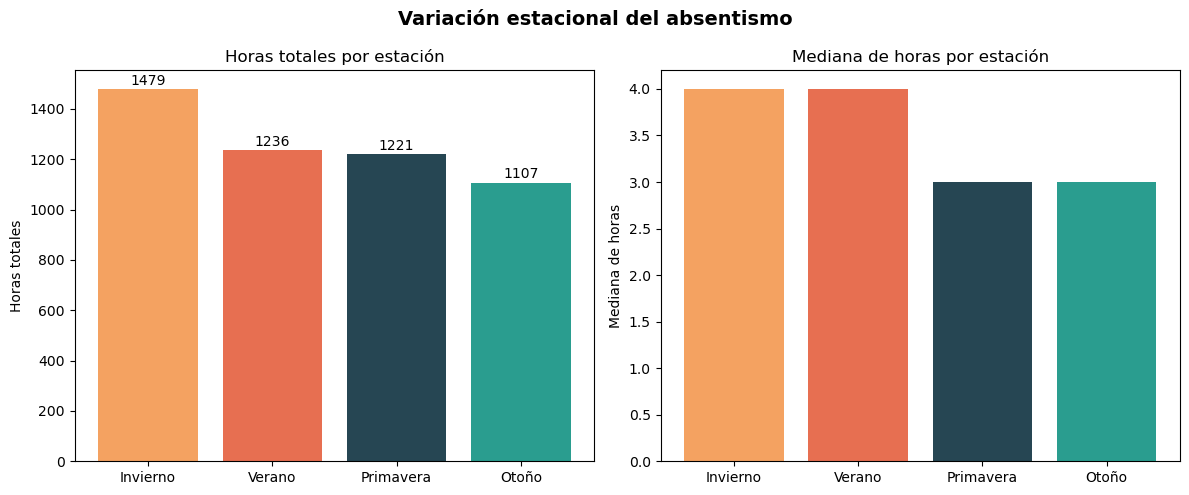

Season_Desc  total_horas  num_episodios  mediana_horas
   Invierno         1479            176            4.0
     Verano         1236            166            4.0
  Primavera         1221            188            3.0
      Otoño         1107            172            3.0


In [104]:
# Absentismo por estación
abs_estacio = df.groupby('Season_Desc')[col].agg(
    total_horas='sum',
    num_episodios='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_est = ['#f4a261', '#e76f51', '#264653', '#2a9d8f']
bars = axes[0].bar(abs_estacio['Season_Desc'], abs_estacio['total_horas'], color=colors_est)
for bar, val in zip(bars, abs_estacio['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por estación')
axes[0].set_ylabel('Horas totales')

axes[1].bar(abs_estacio['Season_Desc'], abs_estacio['mediana_horas'], color=colors_est)
axes[1].set_title('Mediana de horas por estación')
axes[1].set_ylabel('Mediana de horas')

plt.suptitle('Variación estacional del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(abs_estacio[['Season_Desc', 'total_horas', 'num_episodios', 'mediana_horas']].to_string(index=False))

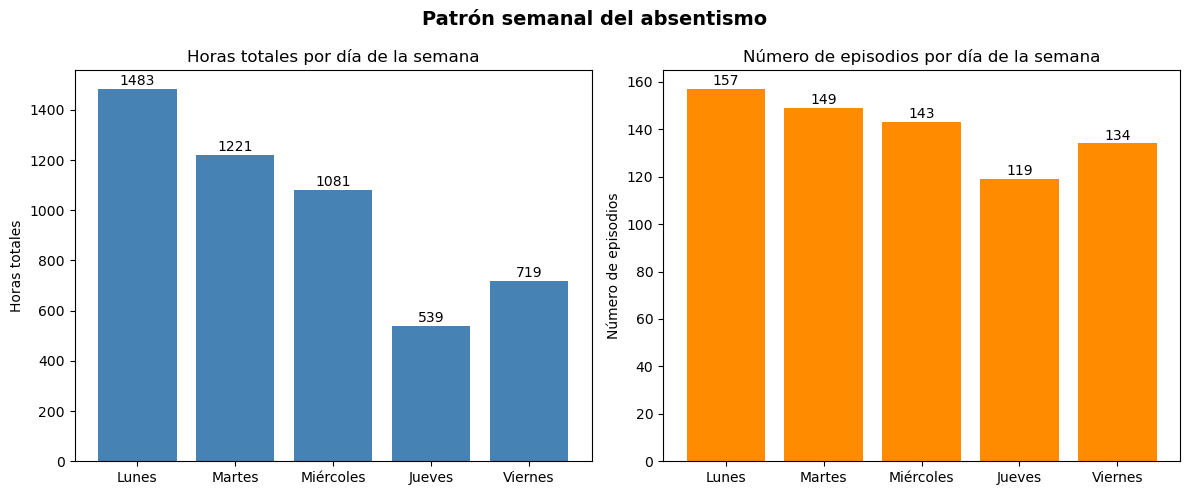

In [105]:
# Absentismo por día de la semana
ordre_dies = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

abs_dia = df.groupby('Day_Week_Desc')[col].agg(
    total_horas='sum',
    num_episodios='count',
    mediana_horas='median'
).reset_index()

# Reordenar según día de la semana
ordre_reals = [d for d in ordre_dies if d in abs_dia['Day_Week_Desc'].values]
abs_dia = abs_dia.set_index('Day_Week_Desc').reindex(ordre_reals).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(abs_dia['Day_Week_Desc'], abs_dia['total_horas'], color='steelblue')
for bar, val in zip(bars, abs_dia['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por día de la semana')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_dia['Day_Week_Desc'], abs_dia['num_episodios'], color='darkorange')
for bar, val in zip(bars2, abs_dia['num_episodios']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[1].set_title('Número de episodios por día de la semana')
axes[1].set_ylabel('Número de episodios')

plt.suptitle('Patrón semanal del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

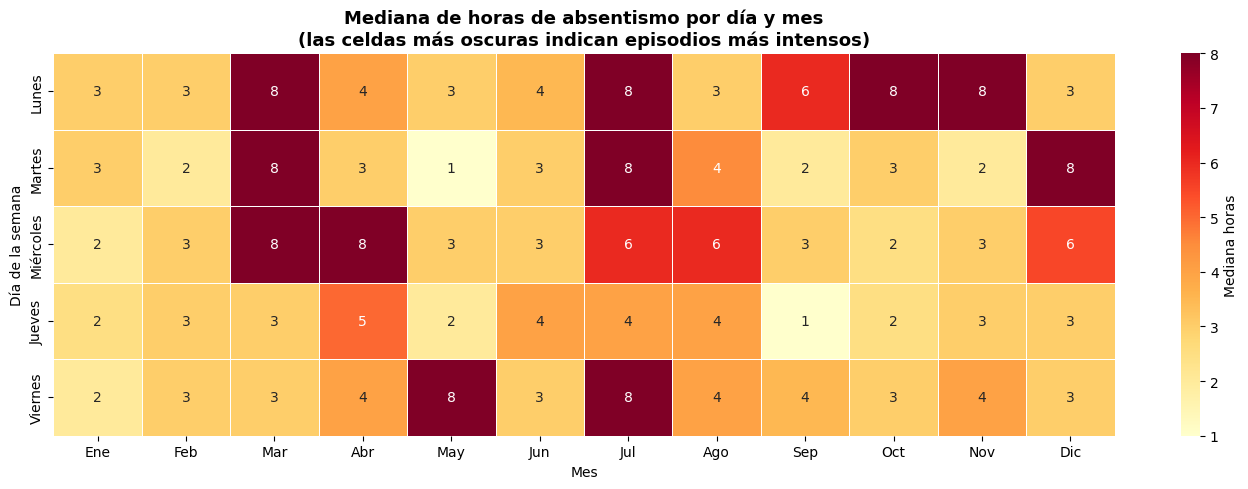

In [106]:
# Heatmap: mes x día de la semana
#¿hay combinaciones de mes+día críticas?
pivot = df_mesos.pivot_table(
    values=col,
    index='Day_Week_Desc',
    columns='Month_Absence_Desc',
    aggfunc='median'
)

ordre_dies_pivot = [d for d in ordre_dies if d in pivot.index]
pivot = pivot.reindex(index=ordre_dies_pivot,
                      columns=[m for m in ordre_mesos if m in pivot.columns])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mediana horas'})
plt.title('Mediana de horas de absentismo por día y mes\n(las celdas más oscuras indican episodios más intensos)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

## 4. Análisis por motivo

dos grupos:

- **Motivos médicos (ICD 1-21):** enfermedades según la clasificación internacional. Difíciles de anticipar / prevenir desde RRHH.
- **Motivos no médicos (22-28):** consultas médicas, fisioterapia, laboratorio, donación de sangre, etc. Sí son planificables por la antelación extra.

In [107]:
# Horas totales por motivo
abs_motiu = df.groupby(['Reason_Absence', 'Reason_Absence_Desc', 'Tipus_Motiu'])[col].agg(
    total_horas='sum',
    num_episodios='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

print('Top 10 motivos por horas totales')
print()
print(abs_motiu[['Reason_Absence_Desc', 'Tipus_Motiu', 'total_horas', 'num_episodios', 'mediana_horas']].head(10).to_string(index=False))

Top 10 motivos por horas totales

                          Reason_Absence_Desc       Tipus_Motiu  total_horas  num_episodios  mediana_horas
  Enfermedades del sistema musculoesquelético Médico ICD (1-21)          842             55            8.0
                   Lesiones y envenenamientos Médico ICD (1-21)          729             40            8.0
                              Consulta médica No médico (22-28)          408            142            2.0
                              Consulta dental No médico (22-28)          329            108            2.0
           Enfermedades del sistema digestivo Médico ICD (1-21)          297             26            8.0
                      Seguimiento de paciente No médico (22-28)          285             37            8.0
        Enfermedades del sistema respiratorio Médico ICD (1-21)          276             25            8.0
                       Ausencia injustificada No médico (22-28)          240             33            8.0
Sín

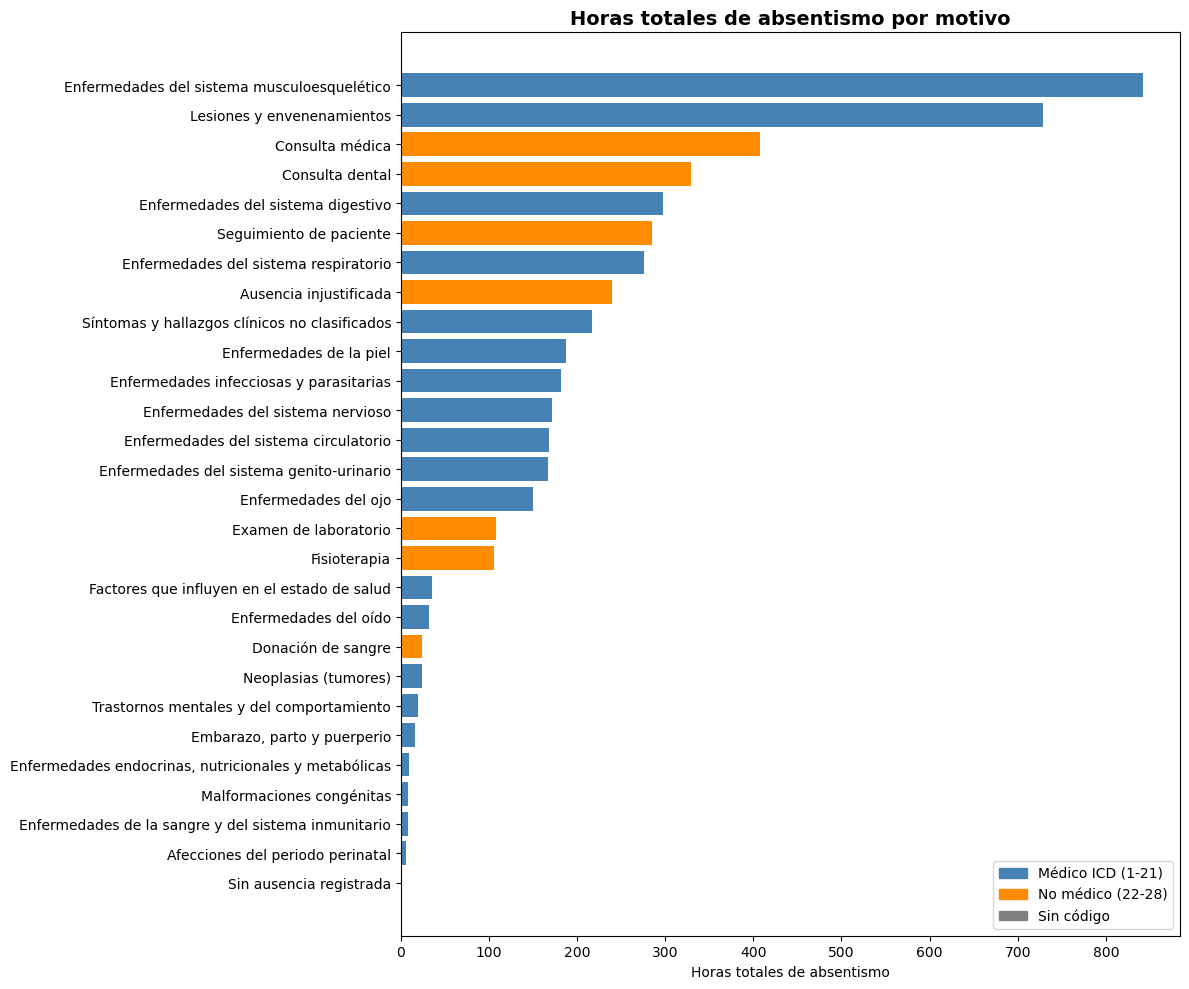

In [108]:
color_map = {
    'Médico ICD (1-21)': 'steelblue',
    'No médico (22-28)': 'darkorange',
    'Sin código': 'grey'
}
colors = abs_motiu['Tipus_Motiu'].map(color_map)

plt.figure(figsize=(12, 10))
plt.barh(abs_motiu['Reason_Absence_Desc'], abs_motiu['total_horas'], color=colors)
plt.xlabel('Horas totales de absentismo')
plt.title('Horas totales de absentismo por motivo', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

llegenda = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=llegenda, loc='lower right')
plt.tight_layout()
plt.show()

 Proporción médico vs no médico (horas totales) 
      Tipus_Motiu  total_horas  pct
Médico ICD (1-21)         3543 70.3
No médico (22-28)         1500 29.7
       Sin código            0  0.0


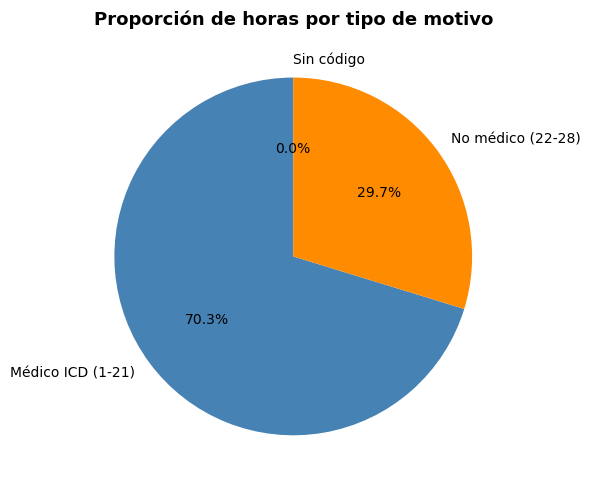

In [109]:
# Proporción médico vs no médico
resum = abs_motiu.groupby('Tipus_Motiu')['total_horas'].sum().reset_index()
resum['pct'] = (resum['total_horas'] / resum['total_horas'].sum() * 100).round(1)

print(' Proporción médico vs no médico (horas totales) ')
print(resum.to_string(index=False))

plt.figure(figsize=(7, 5))
plt.pie(resum['total_horas'], labels=resum['Tipus_Motiu'],
        autopct='%1.1f%%',
        colors=[color_map.get(t, 'grey') for t in resum['Tipus_Motiu']],
        startangle=90)
plt.title('Proporción de horas por tipo de motivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

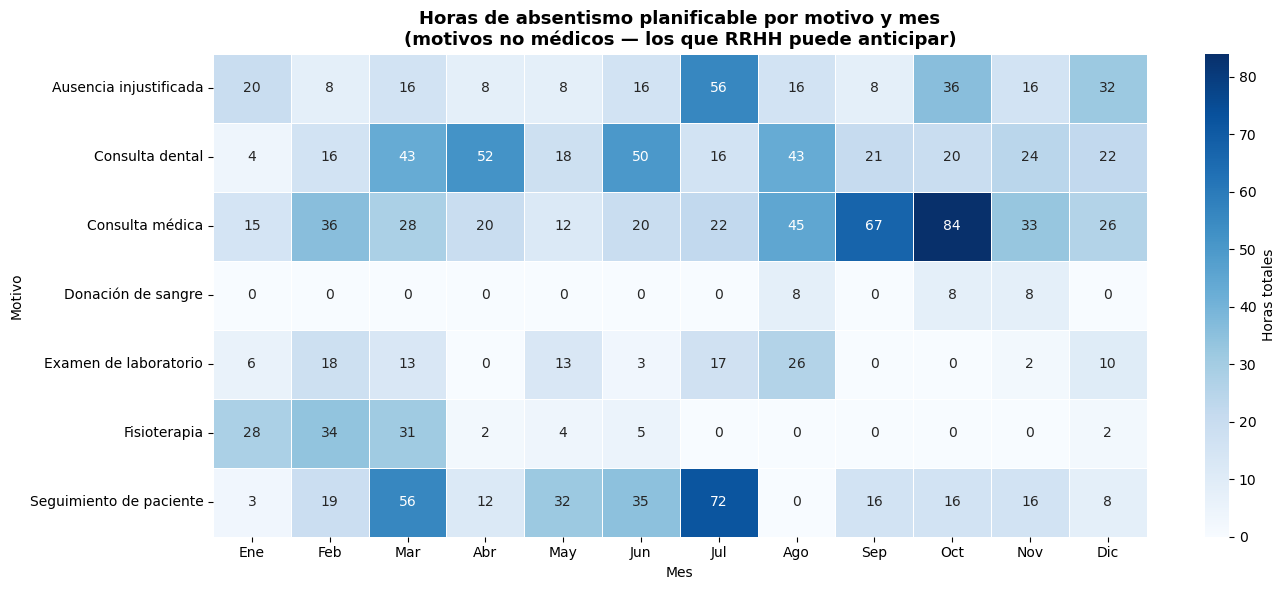

In [116]:
# Heatmap de motivos NO médicos por mes (los planificables)
df_no_medic = df_mesos[df_mesos['Reason_Absence'] >= 22].copy()

pivot_nm = df_no_medic.pivot_table(
    values=col,
    index='Reason_Absence_Desc',
    columns='Month_Absence_Desc',
    aggfunc='sum',
    fill_value=0
)
pivot_nm = pivot_nm[[m for m in ordre_mesos if m in pivot_nm.columns]]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_nm, annot=True, fmt='g', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Horas totales'})
plt.title('Horas de absentismo planificable por motivo y mes\n(motivos no médicos — los que RRHH puede anticipar)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()

## 5. Relación entre absentismo y variables laborales
Variables laborales (carga de trabajo, distancia al trabajo, antigüedad...) relacionadas con la cantidad de horas de absentismo???

**Limitación importante a tener en cuenta:**  
Los registros de absencia no son x personas independientes. Son 36 empleados con múltiples ausencias cada uno. Esto puede afectar artificialmente los coeficientes de correlación.

In [111]:
vars_laborals = [
    'Absenteeism_Hours', 'Work_load_Average_Day', 'Hit_Target',
    'Transportation_Expense', 'Distance_Residence_Work',
    'Service_Time', 'Age'
]

corr_spearman = df[vars_laborals].corr(method='spearman')
corr_abs = corr_spearman['Absenteeism_Hours'].drop('Absenteeism_Hours').sort_values(key=abs, ascending=False)

print(' Correlación de Spearman con Absenteeism_Hours ')
print(corr_abs.round(3))

 Correlación de Spearman con Absenteeism_Hours 
Transportation_Expense     0.152
Age                       -0.061
Hit_Target                 0.044
Service_Time              -0.020
Distance_Residence_Work    0.015
Work_load_Average_Day      0.010
Name: Absenteeism_Hours, dtype: float64


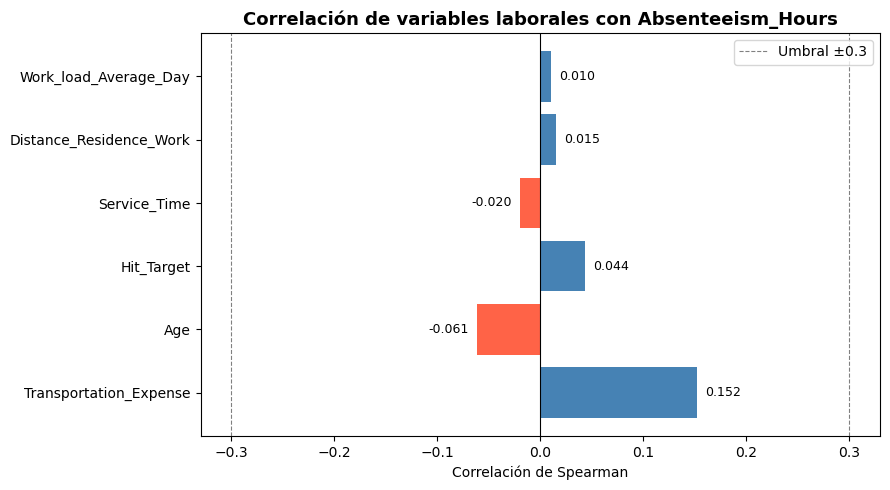

In [117]:
colors_corr = ['steelblue' if v >= 0 else 'tomato' for v in corr_abs]

plt.figure(figsize=(9, 5))
bars = plt.barh(corr_abs.index, corr_abs.values, color=colors_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(0.3, color='grey', linewidth=0.8, linestyle='--', label='Umbral ±0.3')
plt.axvline(-0.3, color='grey', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, corr_abs.values):
    offset = 0.008 if val >= 0 else -0.008
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.xlabel('Correlación de Spearman')
plt.title('Correlación de variables laborales con Absenteeism_Hours', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


 Absentismo según falta disciplinaria 
               count  median  mean
Sin falta (0)    663     4.0  7.61
Con falta (1)     39     0.0  0.00


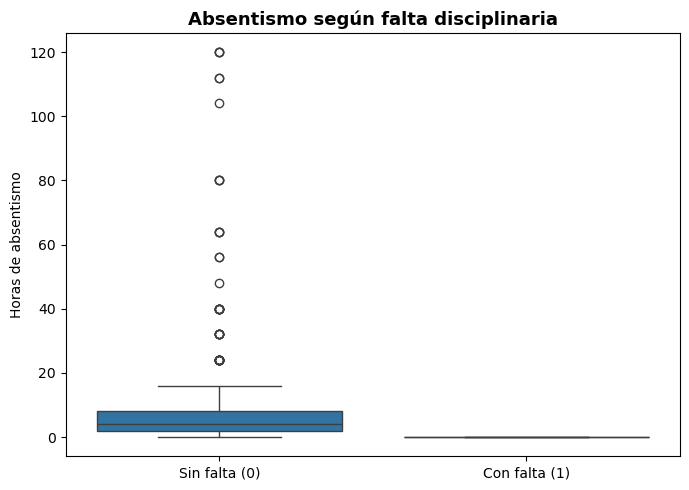

In [113]:
# Absentismo según falta disciplinaria
grups = df.groupby('Disciplinary_Failure')['Absenteeism_Hours'].agg(
    ['count', 'median', 'mean']
).round(2)
grups.index = ['Sin falta (0)', 'Con falta (1)']
print(' Absentismo según falta disciplinaria ')
print(grups)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Disciplinary_Failure', y='Absenteeism_Hours')
plt.xticks([0, 1], ['Sin falta (0)', 'Con falta (1)'])
plt.title('Absentismo según falta disciplinaria', fontsize=13, fontweight='bold')
plt.ylabel('Horas de absentismo')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 6. Conclusiones y recomendaciones de negocio

In [114]:
total_horas = df[col].sum()
mediana_ep = df[col].median()
num_empleats = df['ID_Employee'].nunique()
hores_per_emp = total_horas / num_empleats

mes_max = abs_mes.loc[abs_mes['total_horas'].idxmax(), 'Month_Absence_Desc']
mes_min = abs_mes.loc[abs_mes['total_horas'].idxmin(), 'Month_Absence_Desc']
est_max = abs_estacio.loc[abs_estacio['total_horas'].idxmax(), 'Season_Desc']
dia_max_ep = abs_dia.loc[abs_dia['num_episodios'].idxmax(), 'Day_Week_Desc']
motiu_top = abs_motiu.iloc[0]['Reason_Absence_Desc']

print('   RESUMEN EJECUTIVO — ABSENTISMO LABORAL')
print(f'  Horas totales de absentismo:        {total_horas:,.0f} h')
print(f'  Mediana por episodio:               {mediana_ep:.0f} h')
print(f'  Horas totales por empleado:         {hores_per_emp:.0f} h')
print(f'  Mes con más absentismo:             {mes_max}')
print(f'  Mes con menos absentismo:           {mes_min}')
print(f'  Estación con más absentismo:        {est_max}')
print(f'  Día con más episodios:              {dia_max_ep}')
print(f'  Motivo principal (horas):           {motiu_top}')


   RESUMEN EJECUTIVO — ABSENTISMO LABORAL
  Horas totales de absentismo:        5,043 h
  Mediana por episodio:               3 h
  Horas totales por empleado:         148 h
  Mes con más absentismo:             Mar
  Mes con menos absentismo:           Ene
  Estación con más absentismo:        Invierno
  Día con más episodios:              Lunes
  Motivo principal (horas):           Enfermedades del sistema musculoesquelético


# RECOMENDACIONES DE NEGOCIO:

1. PLANIFICACIÓN ESTACIONAL
   XXXXXXXXXXXXXXXXXXX

2. PATRÓN SEMANAL


3. AUSENCIAS PLANIFICABLES


4. LIMITACIONES DEL ANÁLISIS ???
